# 03 · The certificates on trial

Can a running sampler certify its own output without ground truth? Two
mechanisms have been proposed. This notebook tests both.

## Route one: journey accounting

A steered sampler knows both its own nudged step rules and the unsteered
ones, so it can price its own trajectory. With $p_0$ the unsteered step
probabilities, $p_s$ the steered ones, and $L$ the data fit of the final map,

$$w(\mathrm{trajectory}) \;=\; \prod_t
\frac{p_0(\mathrm{step}_t)}{p_s(\mathrm{step}_t)} \;\cdot\; L(x_0),$$

$$\mathrm{ESS} = \frac{(\sum_i w_i)^2}{\sum_i w_i^2}, \qquad
\widehat{\mathrm{KL}} = \log\langle w \rangle - \langle \log w \rangle .$$

**In words:** every step pays a price for how much the nudge distorted it,
and the product over the trajectory is an exact accounting device. If the
sampler were perfect the weights would be identical across trajectories, so
their spread is a certificate reading. ESS near the sample count means
healthy, ESS near 1 means the books have collapsed onto a single trajectory.
$\widehat{\mathrm{KL}}$ turns the spread into nats of path-space damage.
All of it computable at runtime, no ground truth anywhere.

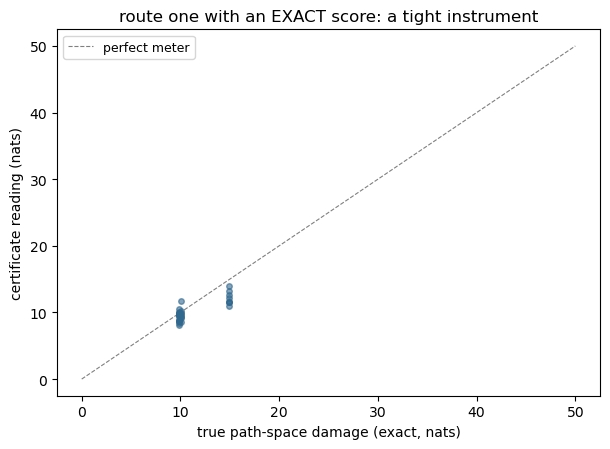

reading/truth over the readable regime: median 0.93, IQR 0.86 to 0.99
(when damage reaches thousands of nats the estimator saturates to a
 lower bound, which is still unmissable)


In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
RES = ROOT / "results"

def rows(name):
    p = RES / name
    if not p.exists():
        print(f"({name} not found, cell skipped)")
        return []
    return [json.loads(l) for l in p.open()]

kt = rows("cert_killtest.jsonl")
readable = [r for r in kt if r.get("score") == "exact"
            and r.get("kl_path_exact") and r["kl_path_exact"] < 50]
fig, ax = plt.subplots(figsize=(6.2, 4.6))
xs = [r["kl_path_exact"] for r in readable]
ys = [r["kl_path_hat"] for r in readable]
ax.plot([0, 50], [0, 50], color="gray", lw=0.8, ls="--",
        label="perfect meter")
ax.plot(xs, ys, "o", ms=4, alpha=0.6, color="#31688e")
ax.set_xlabel("true path-space damage (exact, nats)")
ax.set_ylabel("certificate reading (nats)")
ax.set_title("route one with an EXACT score: a tight instrument")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
r = np.array(ys) / np.array(xs)
print(f"reading/truth over the readable regime: median {np.median(r):.2f}, "
      f"IQR {np.quantile(r,0.25):.2f} to {np.quantile(r,0.75):.2f}")
print("(when damage reaches thousands of nats the estimator saturates to a")
print(" lower bound, which is still unmissable)")

**Reading the scatter.** Each point is one run with the exact score.
Its true path-space damage is on the x axis (computable on this bench only)
and the certificate's runtime reading on the y axis. The points hug the
diagonal. As an instrument on perfect ingredients, route one works.

## Route one dies on trained networks

Swap the exact score for a trained network, everything else identical. The
weights collapse: the network's small, jagged gradient errors accumulate
multiplicatively along hundreds of steps.

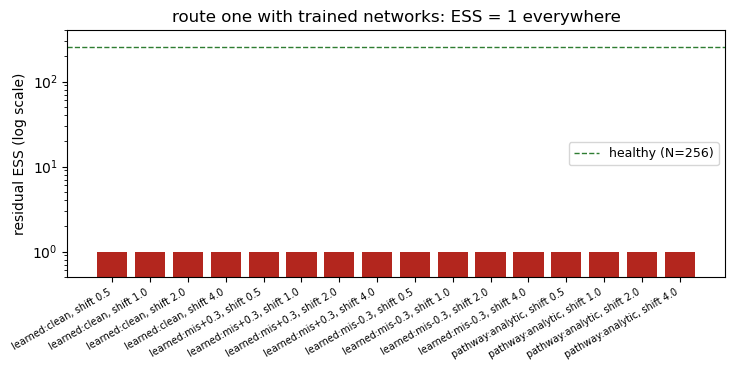

median residual ESS across all learned-net configurations: 1.00 out of 256
one sample carries all the weight. the reading is noise.


In [2]:
cl = rows("cert_learned.jsonl")
learned = [r for r in cl if r.get("score") not in ("exact", "analytic")]
by = defaultdict(list)
for r in learned:
    by[(r.get("score"), r.get("shift"))].append(r["ess_res"])
fig, ax = plt.subplots(figsize=(7.5, 3.8))
labels, vals = [], []
for k in sorted(by, key=str):
    labels.append(f"{k[0]}, shift {k[1]}")
    vals.append(np.median(by[k]))
ax.bar(range(len(vals)), vals, color="#b3261e")
ax.axhline(256, color="#2e7d32", lw=1, ls="--", label="healthy (N=256)")
ax.set_ylabel("residual ESS (log scale)")
ax.set_yscale("log")
ax.set_ylim(0.5, 400)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=7, rotation=30, ha="right")
ax.set_title("route one with trained networks: ESS = 1 everywhere")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"median residual ESS across all learned-net configurations: "
      f"{np.median([r['ess_res'] for r in learned]):.2f} out of 256")
print("one sample carries all the weight. the reading is noise.")

Every bar sits at 1: across networks and steering strengths, a single
trajectory carries the entire ledger, so the reading measures nothing. This
was established through a pre-registered kill test with adversarially checked
escape routes (gentler steering, shorter runs, block-wise books, rankings
instead of absolute readings). None survives. Route one is dead in
deployment.

## Route two: slope checking (score-KSD)

The proposed alternative examines the destination instead of the journey.
The **score** of the target,

$$s(x) = \nabla_x \log \pi(x),$$

**in words** the local uphill direction of the target's probability at the
point $x$, is compared with the arrangement of your samples through a Stein
discrepancy:

$$\mathrm{score\text{-}KSD} = \frac{1}{N}\sqrt{\frac{1}{d}\sum_{i,j}
u_\pi(x_i, x_j)}\,,$$

where $u_\pi$ couples the scores at pairs of samples with a kernel, and a
mathematical identity (due to Stein) guarantees the sum cancels in
expectation exactly when the samples come from $\pi$. **In words:** zero-ish
for a perfect sampler, growing when the sample arrangement disagrees with the
target's slopes. This is the certificate proposed for diffusion inverse
solvers in the recent literature (arXiv:2602.04189). No reference
implementation exists, so this repository contains one, verified against
automatic differentiation, and adds a calibrated detection threshold, which
the paper does not specify.

Before the full-scale trial, the structural weakness can be seen with the
naked eye in two dimensions.

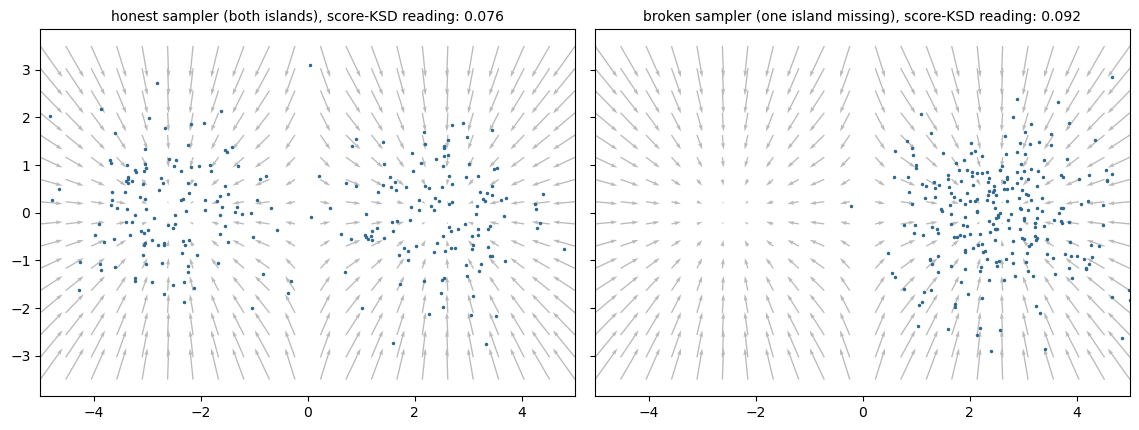

In [3]:
from tilt_audit import ksd as ksdmod

dmu = np.array([2.5, 0.0])
w = 0.5
rng = np.random.default_rng(1)

def sample2(N, mode):
    signs = {"both": rng.choice([-1, 1], N, p=[1 - w, w]),
             "plus": np.ones(N, dtype=int)}[mode]
    return rng.standard_normal((N, 2)) + signs[:, None] * dmu[None, :]

def score2(X):
    la = -0.5 * np.sum((X - dmu) ** 2, axis=1) + np.log(w)
    lb = -0.5 * np.sum((X + dmu) ** 2, axis=1) + np.log(1 - w)
    ra = 1.0 / (1.0 + np.exp(lb - la))
    return (ra[:, None] * (-(X - dmu)) + (1 - ra)[:, None] * (-(X + dmu)))

Xb, Xp = sample2(256, "both"), sample2(256, "plus")
gx, gy = np.meshgrid(np.linspace(-5, 5, 22), np.linspace(-3.5, 3.5, 16))
G = np.stack([gx.ravel(), gy.ravel()], axis=1)
S = score2(G)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for ax, X, title in ((axes[0], Xb, "honest sampler (both islands)"),
                     (axes[1], Xp, "broken sampler (one island missing)")):
    ax.quiver(G[:, 0], G[:, 1], S[:, 0], S[:, 1], color="#bbbbbb",
              width=0.0025, scale=60)
    ax.plot(X[:, 0], X[:, 1], ".", ms=3, color="#31688e")
    st = ksdmod.ksd_stats(X.astype(np.float64),
                          score2(X).astype(np.float64), "imq", 1.0, -0.5)
    ax.set_title(f"{title}, score-KSD reading: {st['score_ksd']:.3f}",
                 fontsize=10)
    ax.set_xlim(-5, 5)
plt.tight_layout()
plt.show()

**Reading the panels.** Gray arrows are the target's score field, the
slopes the certificate checks against. Blue dots are the samples. On the
right, the entire left island of probability is missing, half the posterior,
and the reading barely moves: every sample sits in a region where the local
slopes are exactly what the mixture score says they should be. The score
field around the occupied island does not know the other island is empty.
More samples cannot help, because they all land in the same place.

## The full-scale trial

The same instrument at field scale, on failure archives with exactly known
damage. Detection is at an empirically calibrated 5% false-alarm level, rank
against 60 perfect-sampler readings.

/tmp/ipykernel_1124403/548136620.py:15: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(budgets, ys, "o-", color=color, label=label,


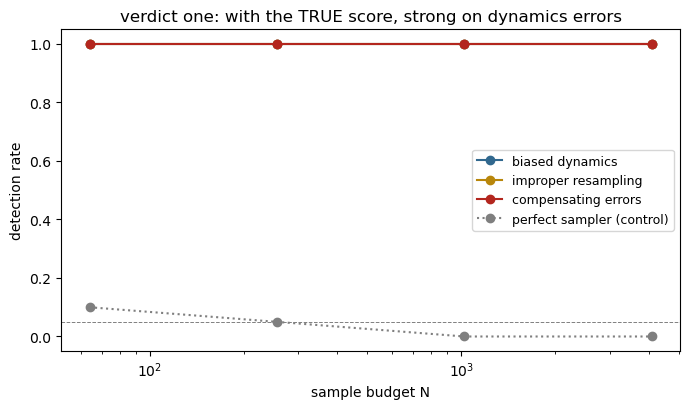

even the compensating-errors configuration (which reads clean on the
temperature diagnostic and needs 4x budget for sample-based tests)
is caught with certainty from 64 samples.


In [4]:
ksd = rows("ksd_trial.jsonl")
power = [r for r in ksd if r.get("arm") == "power"
         and r.get("kernel") == "imq_paper"]
byp = defaultdict(list)
for r in power:
    byp[(r["config"], r["budget"])].append(r["detect"])
budgets = [64, 256, 1024, 4096]
fig, ax = plt.subplots(figsize=(7, 4.2))
for cfg, label, color in (
        ("dps", "biased dynamics", "#31688e"),
        ("sap", "improper resampling", "#b8860b"),
        ("dps_em03", "compensating errors", "#b3261e"),
        ("oracle_null", "perfect sampler (control)", "#7f7f7f")):
    ys = [np.mean(byp.get((cfg, b), [np.nan])) for b in budgets]
    ax.plot(budgets, ys, "o-", color=color, label=label,
            ls=":" if cfg == "oracle_null" else "-")
ax.set_xscale("log")
ax.axhline(0.05, color="gray", lw=0.7, ls="--")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("sample budget N")
ax.set_ylabel("detection rate")
ax.set_title("verdict one: with the TRUE score, strong on dynamics errors")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("even the compensating-errors configuration (which reads clean on the")
print("temperature diagnostic and needs 4x budget for sample-based tests)")
print("is caught with certainty from 64 samples.")

/tmp/ipykernel_1124403/916386631.py:24: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(xs, ys, "o-", color=color, label=label,


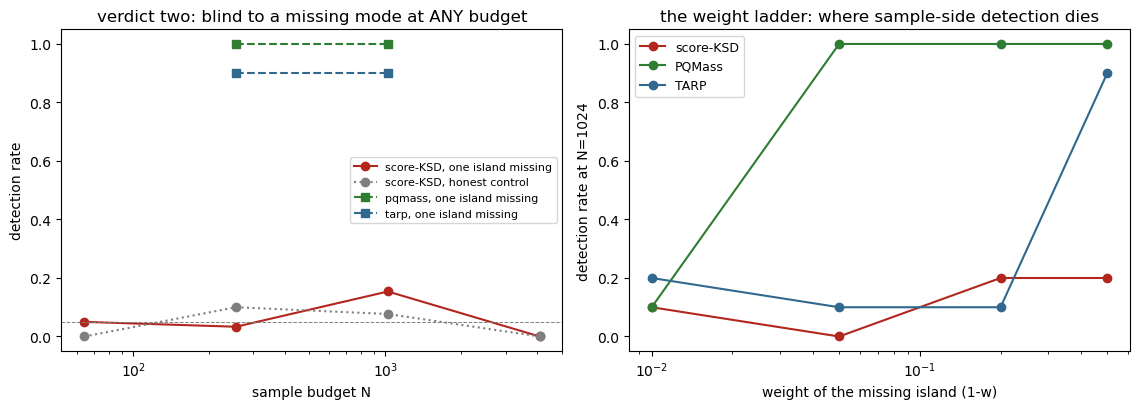

In [5]:
mix = [r for r in ksd if r.get("arm") == "mixture"
       and r.get("kernel") == "imq_paper" and r.get("w") == 0.5]
con = rows("mixture_contrast.jsonl")
bym = defaultdict(list)
for r in mix:
    bym[(r["config"], r["budget"])].append(r["detect"])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
kb = [64, 256, 1024, 4096, 16384]
for cfg, color, label in (
        ("mix_plus", "#b3261e", "score-KSD, one island missing"),
        ("mix_both", "#7f7f7f", "score-KSD, honest control")):
    xs, ys = [], []
    for b in kb:
        v = list(bym.get((cfg, b), []))
        v += [r["detected"] for r in con
              if r.get("test") == "ksd_imq_paper" and r.get("w") == 0.5
              and r["config"] == cfg and r["budget"] == b
              and r.get("detected") is not None]
        if v:
            xs.append(b)
            ys.append(np.mean(v))
    ax.plot(xs, ys, "o-", color=color, label=label,
            ls=":" if cfg == "mix_both" else "-")
# at N=16,384 the paired plus/both statistic ratio is 1.0001 to 1.0007
# (results/mixture_contrast.jsonl, tag exploratory_ckpt1_16k)
for test, color in (("pqmass", "#2e7d32"), ("tarp", "#31688e")):
    xs, ys = [], []
    for b in (256, 1024):
        v = [r["detected"] for r in con if r.get("test") == test
             and r.get("w") == 0.5 and r["config"] == "mix_plus"
             and r["budget"] == b]
        if v:
            xs.append(b)
            ys.append(np.mean(v))
    ax.plot(xs, ys, "s--", color=color, label=f"{test}, one island missing")
ax.set_xscale("log")
ax.axhline(0.05, color="gray", lw=0.7, ls="--")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("sample budget N")
ax.set_ylabel("detection rate")
ax.set_title("verdict two: blind to a missing mode at ANY budget")
ax.legend(fontsize=8)

ax = axes[1]
ws = sorted({r["w"] for r in con})
for test, color, label in (("ksd_imq_paper", "#b3261e", "score-KSD"),
                           ("pqmass", "#2e7d32", "PQMass"),
                           ("tarp", "#31688e", "TARP")):
    xs, ys = [], []
    for w_ in ws:
        v = [r["detected"] for r in con if r.get("test") == test
             and r.get("w") == w_ and r["config"] == "mix_plus"
             and r["budget"] == 1024]
        if v:
            xs.append(1 - w_)
            ys.append(np.mean(v))
    if xs:
        ax.plot(xs, ys, "o-", color=color, label=label)
ax.set_xscale("log")
ax.set_xlabel("weight of the missing island (1-w)")
ax.set_ylabel("detection rate at N=1024")
ax.set_ylim(-0.05, 1.05)
ax.set_title("the weight ladder: where sample-side detection dies")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Reading the left panel.** The red line is the certificate judging a
sampler that misses half the posterior: it never leaves its own false-alarm
floor, out to 16,384 samples. The green and blue points are ordinary
sample-space tests on the same sample sets, at full power. **Right panel:**
turning the missing island rarer. The sample-space tests keep catching it
down to islands holding a few percent of the probability, then die for budget
reasons. The certificate is flat at the floor throughout. The blindness is
structural, not statistical.

## Verdict three: deployment

In practice nobody has the true score. The paper's own recipe builds the
reference from the trained network. Two things happen: the baseline reading
on perfect samples roughly doubles (the network's score error dominates the
statistic), and against that inflated baseline the most-used biased sampler
disappears.

In [6]:
dep = [r for r in ksd if r.get("arm") == "deployment"
       and r.get("kernel") == "imq_paper" and r.get("budget") == 1024]
byd = defaultdict(list)
for r in dep:
    byd[(r["net"], r["config"])].append(r["ratio_q95"])
print("reference score from a trained network (the paper's own recipe),")
print("reading relative to the calibrated null at N=1024:")
print()
print("  judged sampler        net A     net B     true damage")
for cfg, label, dmg in (("oracle_null", "perfect sampler", "none"),
                        ("dps", "plug-in guidance", "30x floor"),
                        ("dps_em03", "compensating errors", "23x floor"),
                        ("sap", "improper resampling", "159x floor")):
    a = np.median(byd.get(("s_clean", cfg), [np.nan]))
    m = np.median(byd.get(("s_mis_m03", cfg), [np.nan]))
    print(f"  {label:20s}  {a:5.2f}x    {m:5.2f}x    {dmg}")
print()
print("plug-in guidance reads BELOW the null with both networks: the")
print("deployed certificate certifies the textbook target as clean. only")
print("catastrophic damage still clears the network-noise floor. a scan of")
print("the recipe's noise-level knob (sigma = 0.1 / 0.3 / 0.6) shows one")
print("setting partially recovers detection, but nothing tells a")
print("practitioner in advance which setting that is.")

reference score from a trained network (the paper's own recipe),
reading relative to the calibrated null at N=1024:

  judged sampler        net A     net B     true damage
  perfect sampler        1.00x     1.00x    none
  plug-in guidance       0.97x     0.98x    30x floor
  compensating errors    1.12x     1.12x    23x floor
  improper resampling    5.24x     5.31x    159x floor

plug-in guidance reads BELOW the null with both networks: the
deployed certificate certifies the textbook target as clean. only
catastrophic damage still clears the network-noise floor. a scan of
the recipe's noise-level knob (sigma = 0.1 / 0.3 / 0.6) shows one
setting partially recovers detection, but nothing tells a
practitioner in advance which setting that is.


## The envelope

The full picture in one matrix, including the coverage tests of the earlier
battery and the budget-doubling check of notebook 04. Strong where designed,
blind where deployment needs it most. That pattern is the project's central
finding.

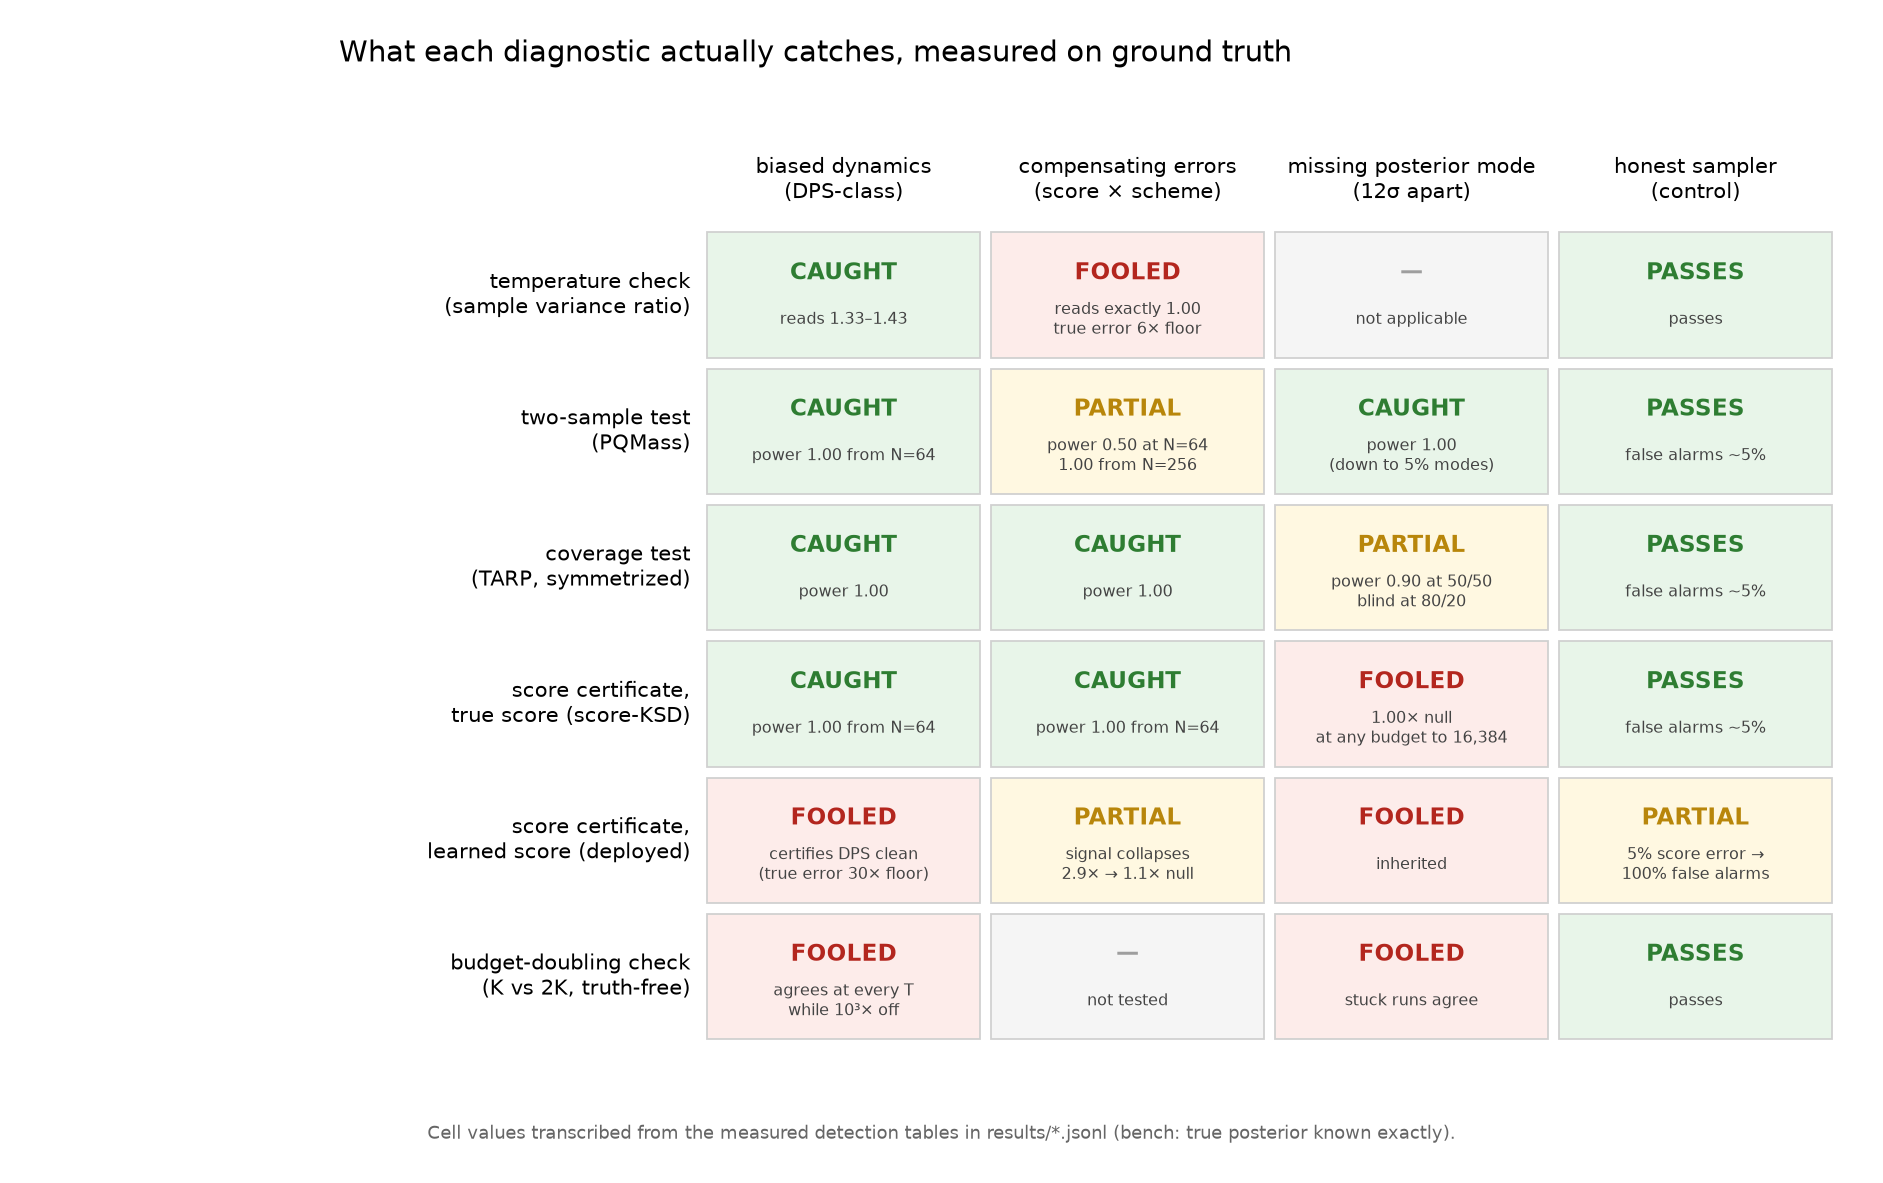

In [7]:
from IPython.display import Image, display
p = ROOT / "figures" / "fig_envelope.png"
if p.exists():
    display(Image(str(p), width=950))